# 130. Malware Detection - Neural Network for Binary Classification

**신경망 기반 악성코드 탐지 시스템**
- 다층 퍼셉트론(MLP)을 이용한 이진 분류
- 악성코드와 정상 파일을 구분하는 딥러닝 모델

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [17]:
# 'malware.csv' 파일을 읽어와 데이터프레임(df)로 저장
# index_col=0 : 첫 번째 열을 데이터프레임의 인덱스로 설정
df = pd.read_csv('malware.csv', index_col=0)

df.head()

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
65416,VirusShare_3ede9b62781398a2e39a0f6af9356a54,3ede9b62781398a2e39a0f6af9356a54,332,224,258,10,0,117760,392192,0,...,5,3.425849,2.458492,4.035538,3146.400000,48,9640,72,15,0
23220,fxsocm.dll,9a0959a682d8eba06d0bd181c49ee2a8,332,224,8462,7,10,112640,29696,0,...,8,3.911994,2.669737,5.335373,1222.750000,164,4889,72,16,1
118017,VirusShare_abe7101746242c922a539ba461db4e38,abe7101746242c922a539ba461db4e38,332,224,258,10,0,119808,385024,0,...,6,3.776760,2.458492,5.317552,2740.166667,48,9640,72,15,0
69842,VirusShare_64a1247fc96d5bc2994ef89ca09adee8,64a1247fc96d5bc2994ef89ca09adee8,332,224,258,10,0,120320,385024,0,...,6,3.756068,2.458492,5.317552,2739.500000,48,9640,72,15,0
22165,asferror.dll,ebc23440aa9cc4f08241d35147c1d5b5,332,224,8462,7,10,0,7168,0,...,2,3.488703,3.471506,3.505901,3050.000000,888,5212,0,16,1


In [18]:
df.shape

(10000, 57)

In [19]:
# 클래스 분포 확인
class_counts = df['legitimate'].value_counts()
print("클래스 분포:")
print(class_counts)
print(f"\n클래스 비율:")
print(f"Malware (0): {class_counts[0]/len(df)*100:.2f}%")
print(f"Legitimate (1): {class_counts[1]/len(df)*100:.2f}%")

클래스 분포:
legitimate
0    7071
1    2929
Name: count, dtype: int64

클래스 비율:
Malware (0): 70.71%
Legitimate (1): 29.29%


In [20]:
df.columns

Index(['Name', 'md5', 'Machine', 'SizeOfOptionalHeader', 'Characteristics',
       'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode',
       'SizeOfInitializedData', 'SizeOfUninitializedData',
       'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase',
       'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion',
       'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion',
       'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage',
       'SizeOfHeaders', 'CheckSum', 'Subsystem', 'DllCharacteristics',
       'SizeOfStackReserve', 'SizeOfStackCommit', 'SizeOfHeapReserve',
       'SizeOfHeapCommit', 'LoaderFlags', 'NumberOfRvaAndSizes', 'SectionsNb',
       'SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy',
       'SectionsMeanRawsize', 'SectionsMinRawsize', 'SectionMaxRawsize',
       'SectionsMeanVirtualsize', 'SectionsMinVirtualsize',
       'SectionMaxVirtualsize', 'ImportsNbDLL', 'ImportsNb',
       'Impor

- Name : 제외
- md5 : hash value 제외

In [21]:
# 데이터프레임에서 모든 행을 유지하고, 두 번째 열(index=1)까지 제외한 나머지 열만 선택하여 새로운 데이터프레임 생성
df = df.iloc[:, 2:]

# 데이터프레임의 차원(행 개수, 열 개수)을 출력
df.shape

(10000, 55)

In [22]:
# 'legitimate' 열을 데이터프레임에서 제거(pop)하고, 해당 열의 값을 y에 저장
y = df.pop('legitimate').values

# 데이터프레임의 나머지 값들을 X에 저장 (입력 데이터)
X = df.values

- Train, Test split

In [23]:
# 데이터를 학습용(train)과 테스트용(test)으로 분할
# test_size=0.2 : 전체 데이터의 20%를 테스트 세트로 사용
# random_state=0 : 실행할 때마다 동일한 방식으로 데이터를 나누도록 설정 (재현성 확보)
# stratify=y : 클래스 비율을 유지하면서 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 54), (2000, 54), (8000,), (2000,))

In [24]:
# StandardScaler 객체 생성 (데이터 표준화를 위한 스케일러)
sc = StandardScaler()

# 학습 데이터(X_train)에 대해 평균을 0, 표준편차를 1로 변환 (표준화 적용)
X_train = sc.fit_transform(X_train)

# 테스트 데이터(X_test)에도 동일한 변환을 적용 (학습 데이터의 기준을 사용하여 변환)
X_test = sc.transform(X_test)

In [25]:
# NumPy 배열을 PyTorch 텐서로 변환 (데이터 타입: float32)
X_train_ts = torch.tensor(X_train, dtype=torch.float32)
X_test_ts = torch.tensor(X_test, dtype=torch.float32)

# 타겟을 PyTorch 텐서로 변환 (데이터 타입: float32)
# .view(-1, 1) : 1D 텐서를 2D 형태(열 벡터)로 변환하여 사용
y_train_ts = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_ts = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

## ``nn.Module``을 이용한 사용자 정의 Neural Network model 정의

**신경망 기반 이진 분류기**: 은닉층이 있는 다층 퍼셉트론(MLP)
- 입력 → 은닉층1 → ReLU → 은닉층2 → ReLU → 출력층 → 시그모이드

In [26]:
# nn.Module을 상속받아 사용자 정의 신경망 모델 클래스를 정의
class MalwareDetectionNN(nn.Module):
    def __init__(self, in_dim, hidden_dim1=128, hidden_dim2=64):
        super(MalwareDetectionNN, self).__init__()

        # 첫 번째 은닉층
        self.linear1 = nn.Linear(in_dim, hidden_dim1)

        # 두 번째 은닉층
        self.linear2 = nn.Linear(hidden_dim1, hidden_dim2)

        # 출력층
        self.linear3 = nn.Linear(hidden_dim2, 1)

        # 활성화 함수
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 첫 번째 은닉층: Linear → ReLU
        x = self.linear1(x)
        x = self.relu(x)

        # 두 번째 은닉층: Linear → ReLU
        x = self.linear2(x)
        x = self.relu(x)

        # 출력층: Linear → Sigmoid
        out = self.sigmoid(self.linear3(x))
        return out

In [27]:
# MalwareDetectionNN 클래스(모델)를 생성할 때, 입력 특성 개수를 X_train.shape[1]로 설정하여 초기화
model = MalwareDetectionNN(X_train.shape[1]).to(device)

# 모델의 구조와 초기화된 파라미터 출력
print("=== 신경망 모델 구조 ===")
print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")
print(f"학습 가능한 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

=== 신경망 모델 구조 ===
MalwareDetectionNN(
  (linear1): Linear(in_features=54, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

총 파라미터 수: 15,361
학습 가능한 파라미터 수: 15,361


In [28]:
# 손실 함수(loss function)로 이진 교차 엔트로피(Binary Cross Entropy) 사용
criterion = nn.BCELoss()

# Adam 옵티마이저 설정
optimizer = optim.Adam(model.parameters(), lr=0.001)

### dataset loader 생성

In [29]:
# torch.utils.data.TensorDataset을 사용하여 학습 데이터셋을 생성
train_ds = torch.utils.data.TensorDataset(X_train_ts, y_train_ts)

# 학습 데이터셋을 DataLoader에 전달하여 데이터 로더를 생성
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=512, shuffle=True)

# 생성한 Neural Network Model Train

In [30]:
# 손실값과 정확도를 저장할 리스트 초기화
train_losses = []
train_accuracies = []

# 하이퍼파라미터 설정
num_epochs = 50
print("=== 신경망 학습 시작 ===")
print(f"총 에포크: {num_epochs}")
print(f"배치 크기: 512")
print("-" * 50)

for epoch in range(num_epochs):
    # 학습 모드 설정
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    # 학습 루프
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        # 순전파
        yhat = model(x)
        loss = criterion(yhat, y)

        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 통계 업데이트
        train_loss += loss.item()
        train_correct += ((yhat > 0.5) == y).sum().item()
        train_total += y.size(0)

    # 평균 계산
    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total

    # 리스트에 저장
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # 진행 상황 출력
    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] - "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")

print(f"\n신경망 학습 완료! 총 {num_epochs} 에포크 실행")

=== 신경망 학습 시작 ===
총 에포크: 50
배치 크기: 512
--------------------------------------------------
Epoch [  1/50] - Train Loss: 0.5668, Train Acc: 0.8253
Epoch [ 10/50] - Train Loss: 0.0380, Train Acc: 0.9885
Epoch [ 20/50] - Train Loss: 0.0272, Train Acc: 0.9906
Epoch [ 30/50] - Train Loss: 0.0205, Train Acc: 0.9932
Epoch [ 40/50] - Train Loss: 0.0139, Train Acc: 0.9959
Epoch [ 50/50] - Train Loss: 0.0105, Train Acc: 0.9970

신경망 학습 완료! 총 50 에포크 실행


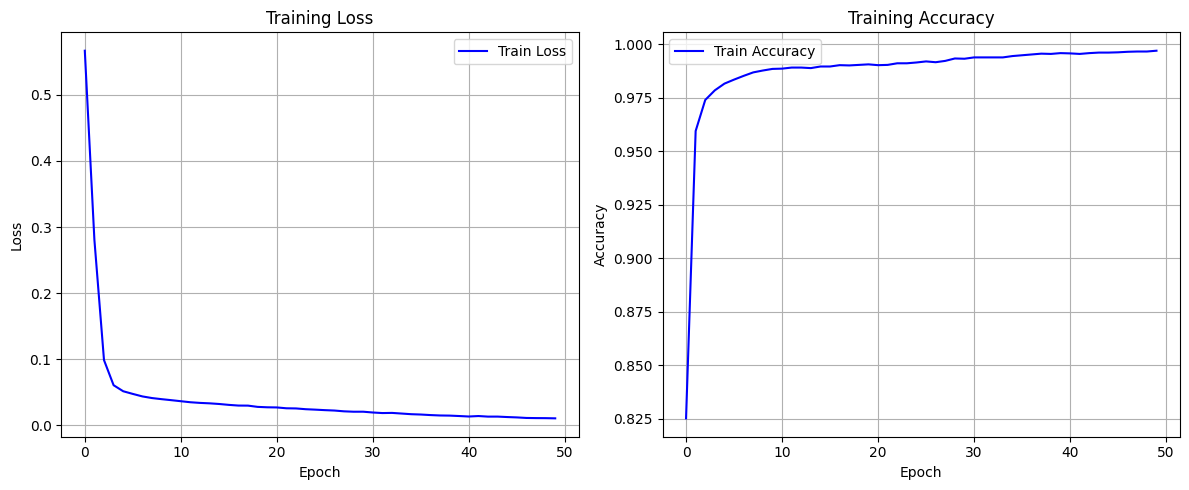

=== 최종 학습 성능 ===
최종 학습 손실: 0.0105
최종 학습 정확도: 0.9970
최고 학습 정확도: 0.9970


In [31]:
# 학습 과정 시각화
plt.figure(figsize=(12, 5))

# 서브플롯 1: 손실 곡선
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 서브플롯 2: 정확도 곡선
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 최종 성능 요약
print("=== 최종 학습 성능 ===")
print(f"최종 학습 손실: {train_losses[-1]:.4f}")
print(f"최종 학습 정확도: {train_accuracies[-1]:.4f}")
print(f"최고 학습 정확도: {max(train_accuracies):.4f}")

In [33]:
# 모델을 평가 모드로 설정
model.eval()

# 테스트 데이터에 대한 예측 수행
with torch.inference_mode():
    X_test_ts = X_test_ts.to(device)
    y_pred_proba = model(X_test_ts)
    y_pred = (y_pred_proba > 0.5).cpu().numpy().flatten()

In [34]:
# 종합적인 평가 메트릭 계산
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== 신경망 모델 성능 평가 ===")
print(f"정확도 (Accuracy): {accuracy:.4f}")
print(f"정밀도 (Precision): {precision:.4f}")
print(f"재현율 (Recall): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

=== 신경망 모델 성능 평가 ===
정확도 (Accuracy): 0.9870
정밀도 (Precision): 0.9714
재현율 (Recall): 0.9846
F1-Score: 0.9780


=== 혼동 행렬 분석 ===
True Negative (TN): 1397 - 정상 파일을 정상으로 올바르게 분류
False Positive (FP): 17 - 정상 파일을 악성으로 잘못 분류 (오탐)
False Negative (FN): 9 - 악성 파일을 정상으로 잘못 분류 (미탐)
True Positive (TP): 577 - 악성 파일을 악성으로 올바르게 분류

오탐률 (False Positive Rate): 0.0120
미탐률 (False Negative Rate): 0.0154


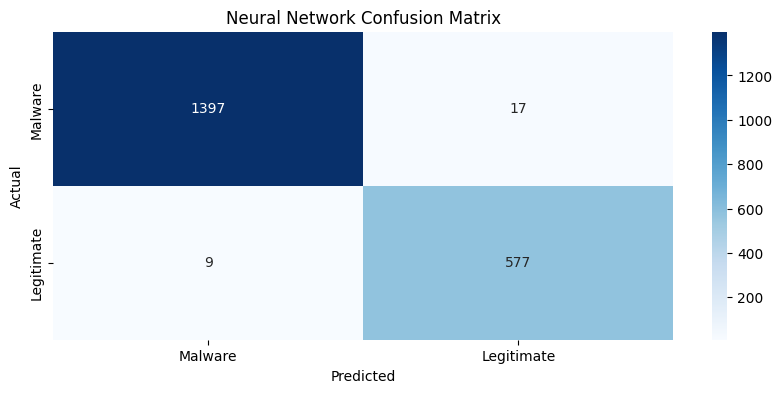

In [35]:
# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 4))

# 서브플롯 1: 혼동 행렬
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malware', 'Legitimate'],
            yticklabels=['Malware', 'Legitimate'])
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

print("=== 혼동 행렬 분석 ===")
print(f"True Negative (TN): {cm[0,0]} - 정상 파일을 정상으로 올바르게 분류")
print(f"False Positive (FP): {cm[0,1]} - 정상 파일을 악성으로 잘못 분류 (오탐)")
print(f"False Negative (FN): {cm[1,0]} - 악성 파일을 정상으로 잘못 분류 (미탐)")
print(f"True Positive (TP): {cm[1,1]} - 악성 파일을 악성으로 올바르게 분류")

# 오탐률과 미탐률 계산
fpr = cm[0,1] / (cm[0,1] + cm[0,0])  # False Positive Rate
fnr = cm[1,0] / (cm[1,0] + cm[1,1])  # False Negative Rate
print(f"\n오탐률 (False Positive Rate): {fpr:.4f}")
print(f"미탐률 (False Negative Rate): {fnr:.4f}")

AUC = 0.9982


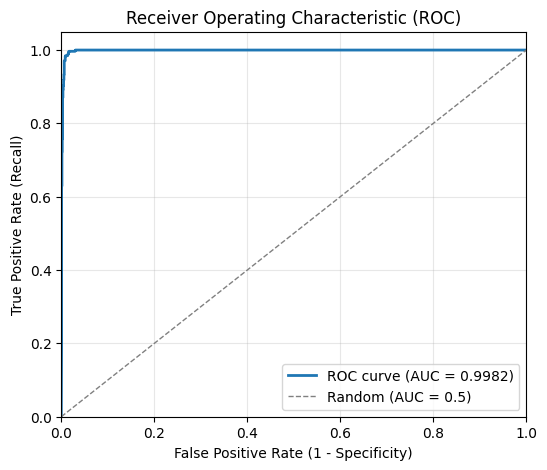


최적 threshold (Youden's J 최대): 0.3021
  → 이 지점의 TPR = 0.9966, FPR = 0.0163


In [36]:
# === ROC 커브 & AUC 계산 (이진 분류 모델 성능 평가) ===
# 위에서 학습한 모델(malware 또는 breast cancer)의 sigmoid 출력 확률(0~1)을 이용해
# ROC 곡선을 그리고 AUC 값을 계산합니다.
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# 1) 모델을 evaluation 모드로 두고 test set 의 "양성 클래스 확률" 추출
#    (malware 모델에서는 위 cell 22 의 y_pred_proba 를 그대로 써도 됩니다)
model.eval()
with torch.inference_mode():
    X_test_dev = X_test_ts.to(device)
    y_proba = model(X_test_dev).cpu().numpy().flatten()

# 2) ROC 곡선 좌표 (FPR, TPR) 와 각 좌표를 만드는 threshold
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# 3) AUC 값  ( 0.5 = random, 1.0 = perfect classifier )
auc = roc_auc_score(y_test, y_proba)
print(f"AUC = {auc:.4f}")

# 4) ROC 시각화
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, ls="--", label="Random (AUC = 0.5)")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#    J = TPR - FPR 가 최대가 되는 지점이 default 0.5 보다 더 좋은 결정 임계값일 수 있음
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\n최적 threshold (Youden's J 최대): {optimal_threshold:.4f}")
print(f"  → 이 지점의 TPR = {tpr[optimal_idx]:.4f}, FPR = {fpr[optimal_idx]:.4f}")

### - Malware Dataset 실습을 바탕으로 다른 이진 분류 문제에도 동일한 MLP 구조를 적용해보세요.

In [38]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X.shape, y.shape

((569, 30), (569,))